In [1]:
# 변수의 shape, type, value 확인
def p(var,_name="") :
    if _name != "" : print(f'<<{_name}>>')
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}')

def pst(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}')

# Pipeline 실습  

## Hugging Face 접근하기    
1 : https://huggingface.co/  
2 : Sing Up   
3 : Email 등록   
4 : confirm email 확인  
5 : Edit profile > Access Tokes > Create new toke > copy   
 [API Token](https://huggingface.co/settings/tokens) 페이지에서 New Token을 생성   
 API 토큰을 Colab secrets에 등록   
 이름 'HF_TOKEN'으로 토큰 저장  

In [2]:
## Colab secrets에서 토큰 불러와서
## os environment에 저장
from google.colab import userdata
import os
#os.environ["HF_TOKEN"] = "hf_YOUR_TOKEN_HERE"
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [3]:
# !huggingface-cli login 필요 없음
!hf auth whoami

user:  gshong
orgs:  LLM2506,aicmap


### library install

In [4]:
import torch
import transformers, accelerate, safetensors  # 기본 설치되어 있음

transformers.__version__,accelerate.__version__,safetensors.__version__
#('4.51.3') 2505
#('4.57.1', '1.11.0', '0.6.2') 2511
#('4.57.6', '1.12.0', '0.7.0') 2601

('4.57.6', '1.12.0', '0.7.0')

## pipeline 사용해보기, [Models](https://huggingface.co/models)    
### 사용가능한 task : HF > Models > Tasks > Natural Language Processing

In [5]:
from transformers import pipeline

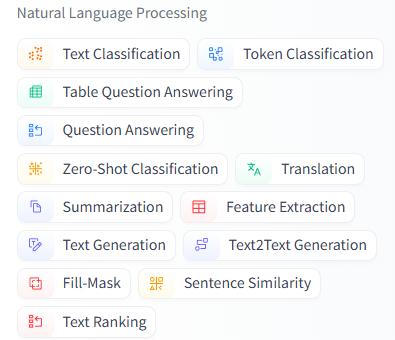

### bert-base-multilingual-cased  
>https://huggingface.co/google-bert/bert-base-multilingual-cased

In [6]:
model = "bert-base-multilingual-cased"   # 1.96MB
task = "fill-mask"
input_text = "The capital of France is [MASK]."
input_text = "안녕! 나는 [MASK] 모델이야."

task_oper = pipeline(task, model=model, tokenizer=model)
task_oper(input_text)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Device set to use cuda:0


[{'score': 0.21458058059215546,
  'token': 62592,
  'token_str': '여자',
  'sequence': '안녕! 나는 여자 모델이야.'},
 {'score': 0.12131957709789276,
  'token': 108399,
  'token_str': '가수',
  'sequence': '안녕! 나는 가수 모델이야.'},
 {'score': 0.0440450981259346,
  'token': 9283,
  'token_str': '모',
  'sequence': '안녕! 나는 모 모델이야.'},
 {'score': 0.03320743516087532,
  'token': 119,
  'token_str': '.',
  'sequence': '안녕! 나는. 모델이야.'},
 {'score': 0.03256179392337799,
  'token': 117,
  'token_str': ',',
  'sequence': '안녕! 나는, 모델이야.'}]

model.safetensors: 100%
 714M/714M [00:02<00:00, 359MB/s]    

-----  
[{'score': 0.21458058059215546,  'token': 62592,  'token_str': '여자',  'sequence': '안녕! 나는 여자 모델이야.'},  
 {'score': 0.12131957709789276,   'token': 108399,  'token_str': '가수',  'sequence': '안녕! 나는 가수 모델이야.'},  
 {'score': 0.0440450981259346,  'token': 9283,  'token_str': '모',  'sequence': '안녕! 나는 모 모델이야.'},  
 {'score': 0.03320743516087532,  'token': 119,  'token_str': '.',  'sequence': '안녕! 나는. 모델이야.'},  
 {'score': 0.03256179392337799,  'token': 117,  'token_str': ',',  'sequence': '안녕! 나는, 모델이야.'}]  

### kykim/gpt3-kor-small_based_on_gpt2  
>https://huggingface.co/kykim/gpt3-kor-small_based_on_gpt2  

In [8]:
model = "kykim/gpt3-kor-small_based_on_gpt2" # 526MB
task = "text-generation"

input_text = "수학은"

task_oper = pipeline(task, model=model, tokenizer=model)

task_oper(input_text,
          max_new_tokens=256,
          num_return_sequences=2,
          truncation=True)
# Wall time: 14 s

Device set to use cuda:0


[{'generated_text': '수학은 수학은 모든 교과의 기본이다.'},
 {'generated_text': '수학은 수학은 수학적 사고력을 바탕으로 한 학습 방법으로, 초등학교 때 배운 것을 중학교 때 다시 재구성하고, 고학년이 되면 다시 익혀야 합니다.'}]

In [10]:
task_oper(input_text,
          max_new_tokens=256,
          num_return_sequences=3,
          truncation=True)

[{'generated_text': '수학은 지난 1일 서울시교육청에서 열린 수학교육진흥 정책간담회에서 이 같은 내용을 담은 초중등 수학교육 활성화 방안을 발표했다.'},
 {'generated_text': '수학은 이 학교 학생들은 교과과정에 있는 수학을 한 곳에서 배울 수 있다.'},
 {'generated_text': '수학은 교육 당국은 지난해 수학교육 정상화와 함께 학교 내신 부풀리기를 막기 위해 수학교육에 대한 대대적인 단속을 시작했다.'}]

[{'generated_text': '수학은  수학은 수학의 기본 개념과 원리를 이해하고, 이를 바탕으로 문제를 해결하는 능력을 말한다.'}]

## PrunaAI의 위치와 역할

**모델 경량화·최적화(Compression / Optimization)** 에 특화    
모델을 싸게·빠르게 실행하도록 지원하는 **배포용 최적화** Tool  

1. 기술적 성과(LLM 기준)
- 파라미터 감소: 30~80%
- Latency 개선: 2~4배
- 정확도 손실: task별로 1~3% 이내 유지

2. 특징
- **Pruning + Quantization + Distillation**의 파이프라인화
- Hugging Face 모델과의 직접 호환성 강조

3. Hugging Face 생태계 반응
- “실험용”이 아니라 실제 서비스 비용을 줄이는 도구로 인식
- 대규모 모델을 다루는 스타트업·엔터프라이즈에서 관심 증가
- 특히 Inference 비용 압박이 큰 LLM 서비스에서 수요가 큼

### PrunaAI/NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed :  
> https://huggingface.co/PrunaAI/NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed
#### OffsetBias :  모델의 성능이나 특성을 미세 조정하는 기법  
#### 8B : #p 80억    
#### bnb-8bit :  "bitsandbytes"로 8bit 양자화   
#### smashed : "PrunaAI"에서 제공하는 모델 경량화, 최적화 기법

In [11]:
## bitsandbytes install & import를 transformer import 보다 앞에 두어야 모델을 읽어 올 수 있음
## 버전에 따라 달라 질 수 있음

!pip install bitsandbytes -q

import bitsandbytes
bitsandbytes.__version__
#0.49.1 2601

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 40.2 MB/s eta 0:00:00


'0.49.1'

In [12]:
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [13]:
%%time

task = "text-generation"
#model_name = "PrunaAI/NCSOFT-Llama-3-OffsetBias-8B-bnb-8bit-smashed"
model_name = "google/gemma-3-4b-it"

task_oper = pipeline(task=task, model=model_name, device_map="auto")

# Wall time: 45 s

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Device set to use cuda:0


CPU times: user 29.8 s, sys: 23.2 s, total: 53 s
Wall time: 43.7 s


In [14]:
%%time
## 두가지 질문에 각각 두가지 답변 생성하기 ##

input_text = ["머신러닝에서 지도 학습과 비지도 학습의 주요 차이점을 설명해줘.3줄 이내로.",
              "너의 지적 수준을 객관적으로 설명해봐. 7줄 이내로 설명해줘.", ]

# batch_size=2 : 토크나이저는 시퀀스 길이를 맞추기 위해 패딩 토큰이 필요
#task_oper.tokenizer.pad_token_id = task_oper.model.config.eos_token_id

output = task_oper(input_text,
                   max_new_tokens=512,   # 생성할 최대 토큰 수
                  do_sample=True,        # token 확률에서 sampling
                  temperature=0.7,       # 큰 값일 수록 낮은 확률의 token을 선택
                  top_p=0.9,             # 누적확률 90%까지 sampling에 포함
                  num_return_sequences=2,# 두가지 답변을 준비
                  batch_size=2           # 두가지 질문을 처리
                  )

# Wall time: 37.7 s : 답변길이 제한하지 않을경우
# Wall time: 9.09 s : 3줄로 제한한 경우

CPU times: user 33.1 s, sys: 114 ms, total: 33.2 s
Wall time: 33.5 s


In [15]:
print(output[0][0]['generated_text'])
print("\n=======\n")
print(output[0][1]['generated_text'])
print("\n=======\n")
print(output[1][0]['generated_text'])
print("\n=======\n")
print(output[1][1]['generated_text'])

머신러닝에서 지도 학습과 비지도 학습의 주요 차이점을 설명해줘.3줄 이내로.

**지도 학습:** 레이블이 지정된 데이터로 모델을 학습시켜 입력 데이터에 대한 예측을 수행합니다. 즉, 정답이 있는 데이터를 사용하여 모델이 학습하는 방식입니다.
**비지도 학습:** 레이블이 없는 데이터로 모델을 학습시켜 데이터 자체의 패턴이나 구조를 발견합니다. 데이터의 숨겨진 특징을 스스로 학습하는 방식입니다.
**핵심 차이:** 지도 학습은 예측, 비지도 학습은 탐색에 중점을 둡니다.


머신러닝에서 지도 학습과 비지도 학습의 주요 차이점을 설명해줘.3줄 이내로.

*   **지도 학습:** 레이블이 있는 데이터를 사용하여 모델을 훈련시켜 입력과 출력 간의 관계를 학습합니다. 즉, 정답이 주어져 예측을 수행합니다.
*   **비지도 학습:** 레이블이 없는 데이터를 사용하여 데이터 자체의 패턴이나 구조를 발견합니다. 정답 없이 숨겨진 정보를 찾아냅니다.
*   **핵심 차이:** 지도 학습은 예측, 비지도 학습은 탐색에 초점을 맞춥니다.


너의 지적 수준을 객관적으로 설명해봐. 7줄 이내로 설명해줘.

저는 현재 대학생으로, 다양한 분야에 대한 지식을 쌓고 있습니다. 특히, 과학, 기술, 철학, 역사 등 폭넓은 분야에 관심을 가지고 탐구하며, 새로운 아이디어를 창출하고 비판적으로 사고하는 능력을 키우기 위해 노력하고 있습니다.

저는 학업 성적도 우수하며, 논리적이고 체계적인 사고를 할 수 있습니다. 또한, 다양한 사람들과 소통하고 협력하며, 자신의 생각을 효과적으로 전달하는 능력도 갖추고 있습니다.

하지만, 저는 아직 부족한 점도 많습니다. 특히, 특정 분야에 대한 깊이 있는 지식은 부족하며, 때로는 과도하게 분석하거나 비판적으로만 접근하는 경향이 있습니다.

저는 끊임없이 배우고 성장하며, 더 나은 사람이 되기 위해 노력할 것입니다.

저는 현재 140-150 정도라고 생각합니다. (IQ 테스트 점수 참고)

**참고:** IQ 테스트 점수는 개인차가 크므로, 이는 

In [ ]:
output

[[{'generated_text': '머신러닝에서 지도 학습과 비지도 학습의 주요 차이점을 설명해줘.3줄 이내로.\n\n**지도 학습:** 레이블이 있는 데이터(정답)를 사용하여 모델을 학습시켜 새로운 데이터에 대한 예측을 수행하는 방식입니다.\n**비지도 학습:** 레이블이 없는 데이터에서 패턴, 구조 또는 관계를 찾는 방식으로, 모델이 스스로 데이터를 이해하도록 돕습니다.\n**핵심 차이:** 지도 학습은 예측, 비지도 학습은 탐색에 초점을 맞춥니다.'},
  {'generated_text': '머신러닝에서 지도 학습과 비지도 학습의 주요 차이점을 설명해줘.3줄 이내로.\n\n**지도 학습:** 레이블이 있는 데이터를 사용하여 모델을 학습시키고, 입력 데이터에 대한 예측을 수행합니다. 즉, 정답을 알려주면서 학습하는 방식입니다.\n\n**비지도 학습:** 레이블이 없는 데이터를 사용하여 모델을 학습시키고, 데이터 자체의 패턴이나 구조를 발견합니다. 즉, 정답 없이 스스로 학습하는 방식입니다.\n\n**핵심 차이:** 지도 학습은 예측, 비지도 학습은 탐색에 초점을 맞춥니다.\n'}],
 [{'generated_text': '너의 지적 수준을 객관적으로 설명해봐. 7줄 이내로 설명해줘.\n\n나는 꽤 높은 수준의 지적 능력을 가지고 있다고 생각한다. 학부 시절에는 과학 분야에서 뛰어난 성적을 거두었고, 대학원 과정에서도 박사 학위를 받았다. 특히, 논리적 사고와 문제 해결 능력은 매우 뛰어나며, 복잡한 개념을 빠르게 이해하고 적용하는 데 능숙하다. 또한, 다양한 분야에 대한 폭넓은 지식과 끊임없는 학습 의욕을 가지고 있다. 하지만, 때로는 지나치게 분석적인 성향 때문에 실용적인 판단을 내리기 어려울 때도 있다.\n\n이 답변이 도움이 되었기를 바랍니다. 혹시 다른 질문이 있다면 언제든지 물어보세요.'},
  {'generated_text': '너의 지적 수준을 객관적으로 설명해봐. 7줄 이내로 설명해줘.\n\n저는 다양한 분야에 대한 폭넓은 지식을 가지고 

Generated Text:
머신러닝에서 지도 학습과 비지도 학습의 주요 차이점을 설명해줘.

지도 학습( supervised learning )과 비지도 학습(unsupervised learning)은 머신러닝의 두 가지 주요 유형입니다.

지도 학습은 훈련 데이터에 레이블이 할당된 상태에서 모델을 훈련하는 방식입니다. 예를 들어, 이미지 분류에서 이미지에 레이블이 할당된 경우, 모델은 이 레이블을 예측하는 것을 목표로 합니다. 이 방법으로 모델이 훈련되면, 예측 정확도가 향상됩니다.

비지도 학습은 훈련 데이터에 레이블이 할당되지 않은 상태에서 모델을 훈련하는 방식입니다. 예를 들어, 고객 Segmentation에서 고객을 그룹으로 나누는 경우, 모델은 데이터의 패턴을 찾아내어 그룹을 생성합니다. 이 방법으로 모델이 훈련되면, 데이터의 구조를 이해하는 데 도움이 됩니다.

따라서, 지도 학습의 목표는 훈련 데이터에 레이블이 할당된 예측을 만들고, 비지도 학습의 목표는 훈련 데이터의 구조를 이해하는 것입니다.

따라서, 지도 학습은 훈련 데이터에 레이블

**Model중에서 bitandbytes로 양자화된 모델을 load해 보자**잘 되는가?   

## Colab에서 bitsandbytes 오류가 자주 발생하는 이유  

    Colab 환경은 매우 자주 업데이트되며, 다음과 같은 구조적 호환성 문제 때문에   
    bitsandbytes(특히 8bit/4bit) 모델 로드시 오류가 자주 발생함  

    (1) CUDA 버전 불일치
    bitsandbytes는 특정 CUDA 버전에 대해 컴파일된 wheel을 제공합니다.  
    Colab의 CUDA 버전은 수시로 바뀌며(예: 12.1→12.2→11.8→12.0),  
    bitsandbytes가 제공하는 wheel과 맞지 않으면 ImportError가 발생합니다.  

    (2) GPU 종류 / Compute Capability 문제  
    bitsandbytes는 A100, T4, L4 등 일부 GPU만 공식 지원.  
    Colab에서 L4로 바뀐 뒤 일부 4bit 연산이 정상적으로 작동하지 않는 경우 보고됨.  

    (3) pip로 설치되는 버전이 모델 요구 버전과 충돌  
    HF 모델 카드가 요구하는 bitsandbytes 버전과,  
    Colab 기본 설치 버전이 맞지 않으면 오류가 발생.  

    (4) trust_remote_code 모델의 bnb custom kernel 호출 충돌  
    Llama 계열, Qwen 계열의 커스텀 kernel에서 bnb와 충돌하는 사례가 증가.  

    ==> 점점더 bitsandbytes 기반 모델을 안정적으로 로드하기 어려운 환경이 되어가고 있음



### 최근 Hugging Face에서 GGUF 모델이 급증하는 이유

    GGUF 모델이 많아진 가장 큰 이유는 bitsandbytes 때문이라기 보다는  
    Local GPU/CPU 실행 환경 확장 때문이지만   
    bitsandbytes 불안정성도 간접적 요인으로 작용하고 있음   

    (1) GPU 없이 CPU에서도 고속 실행 가능
    GGUF는 llama.cpp 포맷이며 CPU에서도 꽤 빠르게 동작함.
    Windows / macOS / Linux / 모바일까지 실행 가능.
    GPU가 필요 없는 환경에서 매우 선호됨.

    (2) 전용 런타임이 안정적
    llama.cpp, KoboldCpp, ollama, LM Studio 등에서 GGUF만 쓰면 됨.
    CUDA 버전, bitsandbytes 호환성 문제 없음.
    설치가 매우 단순 (“모델 파일 한 개”).

    (3) 모델 배포자가 관리하기 쉬움
    한 번 GGUF로 변환해두면 사용자 환경을 신경쓸 필요 없음.
    반면 BNB는 CUDA 버전, GPU 종류에 따라 실행 제한 발생.

    (4) 메모리 사용량이 더 낮음
    GGUF는 Q3_K_M, Q4_K_M 등 다양한 양자화 제공 → RAM 사용 절감.

    (5) 로컬 설치 사용자 폭발적 증가
    2024년 이후 로컬LLM 사용자가 폭증하며 GGUF 모델 중심으로 생태계가 이동.

    ==> GGUF는 안정성 + 실행 환경 다양성 때문에 사실상 표준 포맷처럼 됨.

# 실습과제   
## Hugging Face에서 모델을 선택하여 pipeline을 통해 실행해 보자  
### task에 따라 작동을 확인해 보자
### Model page에 #P와 momory사용량을 비교해 보자
### 몇가지 모델을 실험해 보자, Quantized 모델과 비교해 보자  


**주요 모델 요약 (30B 이하)**

모델 | 파라미터 |	공개 시점 |	성능(종합)	| 추론 속도| 특징 요약
|--|--|--|--|--|--|
Meta LLaMA-3 8B | 8B |	2024.04 |	★★★★☆ |	★★★★☆	| 8B 기준 가성비 최고, 범용성 우수
Alibaba Qwen2.5 7B / 14B |	7B / 14B	| 2024.10~12 |	★★★★☆	| ★★★★☆	| 코딩·수학 강점, 다국어 안정  
DeepSeek DeepSeek-R1-Distill-Qwen 7B / 14B |	7B / 14B	|2025.01	|★★★★★	|★★★☆☆	|추론(Reasoning) 특화, CoT 강함
Mistral AI Mistral-Nemo 12B	|12B	|2024.07	|★★★★☆	|★★★★☆	|속도·메모리 효율 우수
Google Gemma-2 9B	|9B	|2024.06	|★★★★☆	|★★★★☆	|안정적 품질, 경량 배포 용이
Microsoft Phi-3.5 Medium |	~14B |	2024.09	|★★★★☆	|★★★★★	|소형 대비 최고 속도, 모바일/엣지 친화

https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct   

https://huggingface.co/Qwen/Qwen2.5-14B-Instruct  

https://huggingface.co/Qwen/Qwen2.5-7B-Instruct  

https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-7B

https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-14B

https://huggingface.co/google/gemma-2-9b